In [1]:
import pandas as pd
import seaborn as sns
import numpy as np

In [2]:
df=pd.read_csv(r"C:\Users\Jeevan kumar\Downloads\bhp.csv")
df.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250


In [3]:
df.shape

(13200, 7)

In [4]:
df.price_per_sqft.describe()

count    1.320000e+04
mean     7.920337e+03
std      1.067272e+05
min      2.670000e+02
25%      4.267000e+03
50%      5.438000e+03
75%      7.317000e+03
max      1.200000e+07
Name: price_per_sqft, dtype: float64

In [5]:
min_p,max_p=df.price_per_sqft.quantile([.001,.999])
min_p,max_p

(1366.184, 50959.36200000098)

In [6]:
outliers=df[(df['price_per_sqft']<min_p) | (df['price_per_sqft']>max_p)]
outliers

,location,size,total_sqft,bath,price,bhk,price_per_sqft
345,other,3 Bedroom,11.0,3.0,74.0,3,672727
665,Yelahanka,3 BHK,35000.0,3.0,130.0,3,371
798,other,4 Bedroom,10961.0,4.0,80.0,4,729
1005,other,1 BHK,15.0,1.0,30.0,1,200000
1106,other,5 Bedroom,24.0,2.0,150.0,5,625000
1867,other,3 Bedroom,52272.0,2.0,140.0,3,267
2392,other,4 Bedroom,2000.0,3.0,25.0,4,1250
3934,other,1 BHK,1500.0,1.0,19.5,1,1300
4044,Sarjapur Road,4 Bedroom,1.0,4.0,120.0,4,12000000
4924,other,7 BHK,5.0,7.0,115.0,7,2300000


In [7]:
df1=df[(df['price_per_sqft']>min_p) & (df['price_per_sqft']<max_p)]
df1

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250
...,...,...,...,...,...,...,...
13195,Whitefield,5 Bedroom,3453.0,4.0,231.00,5,6689
13196,other,4 BHK,3600.0,5.0,400.00,4,11111
13197,Raja Rajeshwari Nagar,2 BHK,1141.0,2.0,60.00,2,5258
13198,Padmanabhanagar,4 BHK,4689.0,4.0,488.00,4,10407


In [8]:
df1.price_per_sqft.describe()

count    13172.000000
mean      6663.653735
std       4141.020700
min       1379.000000
25%       4271.000000
50%       5438.000000
75%       7311.000000
max      50349.000000
Name: price_per_sqft, dtype: float64

<Axes: >

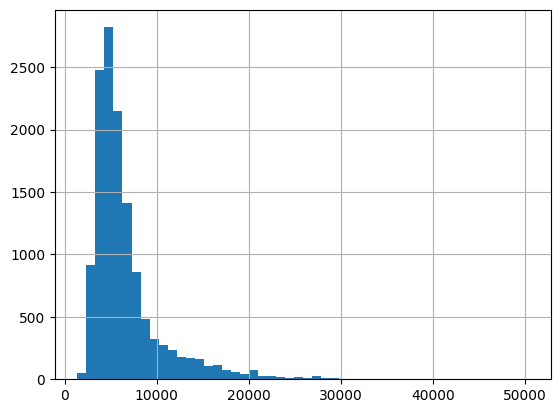

In [9]:
df1.price_per_sqft.hist(bins=50)

In [10]:
min_s=df.price_per_sqft.mean()-3*df.price_per_sqft.std()
max_s=df.price_per_sqft.mean()+3*df.price_per_sqft.std()
min_s,max_s

(np.float64(-312261.14424190175), np.float64(328101.8177267502))

In [11]:
df[(df.price_per_sqft>max_s) | (df.price_per_sqft<min_s)]

,location,size,total_sqft,bath,price,bhk,price_per_sqft
345,other,3 Bedroom,11.0,3.0,74.0,3,672727
1106,other,5 Bedroom,24.0,2.0,150.0,5,625000
4044,Sarjapur Road,4 Bedroom,1.0,4.0,120.0,4,12000000
4924,other,7 BHK,5.0,7.0,115.0,7,2300000
11447,Whitefield,4 Bedroom,60.0,4.0,218.0,4,363333


In [12]:
df2=df[(df.price_per_sqft<max_s) & (df.price_per_sqft>min_s)]
df2.sample(5)

,location,size,total_sqft,bath,price,bhk,price_per_sqft
6956,Jakkur,2 BHK,1202.0,2.0,79.00,2,6572
5648,Attibele,2 BHK,850.0,1.0,25.00,2,2941
479,other,3 BHK,1464.0,3.0,56.00,3,3825
9026,Varthur,2 BHK,1091.0,2.0,33.82,2,3099
1025,Panathur,3 BHK,1315.0,2.0,54.80,3,4167


In [13]:
df2.price_per_sqft.describe()

count     13195.000000
mean       6713.708602
std        4876.727718
min         267.000000
25%        4266.500000
50%        5434.000000
75%        7313.000000
max      200000.000000
Name: price_per_sqft, dtype: float64

<Axes: >

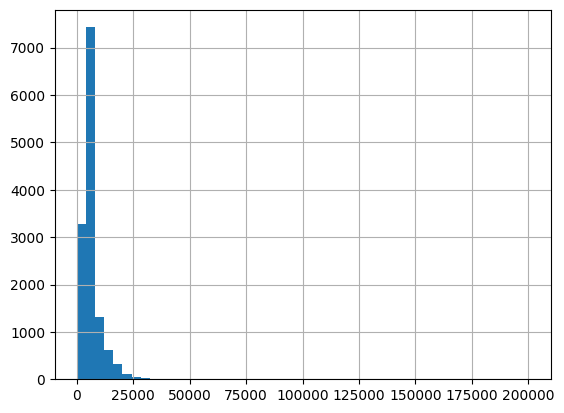

In [14]:
df2.price_per_sqft.hist(bins=50)

In [15]:
df2['z_score']=(df2.price_per_sqft-df2.price_per_sqft.mean())/df2.price_per_sqft.std()
df2.sample()

C:\Users\Jeevan kumar\AppData\Local\Temp\ipykernel_8320\2539340427.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['z_score']=(df2.price_per_sqft-df2.price_per_sqft.mean())/df2.price_per_sqft.std()


,location,size,total_sqft,bath,price,bhk,price_per_sqft,z_score
1682,Ulsoor,2 BHK,1275.0,2.0,120.0,2,9411,0.553095


In [16]:
outliers_z=df2[(df2.z_score<-4) | (df2.z_score>4)]
outliers_z

,location,size,total_sqft,bath,price,bhk,price_per_sqft,z_score
9,other,6 Bedroom,1020.0,6.0,370.0,6,36274,6.061501
45,HSR Layout,8 Bedroom,600.0,9.0,200.0,8,33333,5.458433
190,Bellandur,4 Bedroom,1200.0,5.0,325.0,4,27083,4.176836
760,other,9 Bedroom,600.0,9.0,190.0,9,31666,5.116605
849,other,4 Bedroom,2400.0,4.0,640.0,4,26666,4.091328
...,...,...,...,...,...,...,...,...
13081,other,6 Bedroom,8000.0,6.0,2800.0,6,35000,5.800261
13094,other,4 Bedroom,1200.0,5.0,325.0,4,27083,4.176836
13127,other,4 Bedroom,1200.0,5.0,325.0,4,27083,4.176836
13185,Hulimavu,1 BHK,500.0,1.0,220.0,1,44000,7.645760


In [17]:
df3=df2[(df2.z_score>-4) & (df2.z_score<4)]
df3

,location,size,total_sqft,bath,price,bhk,price_per_sqft,z_score
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699,-0.618183
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615,-0.430352
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305,-0.493919
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245,-0.096111
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250,-0.505197
...,...,...,...,...,...,...,...,...
13195,Whitefield,5 Bedroom,3453.0,4.0,231.00,5,6689,-0.005067
13196,other,4 BHK,3600.0,5.0,400.00,4,11111,0.901689
13197,Raja Rajeshwari Nagar,2 BHK,1141.0,2.0,60.00,2,5258,-0.298501
13198,Padmanabhanagar,4 BHK,4689.0,4.0,488.00,4,10407,0.757330


<Axes: xlabel='price_per_sqft', ylabel='Count'>

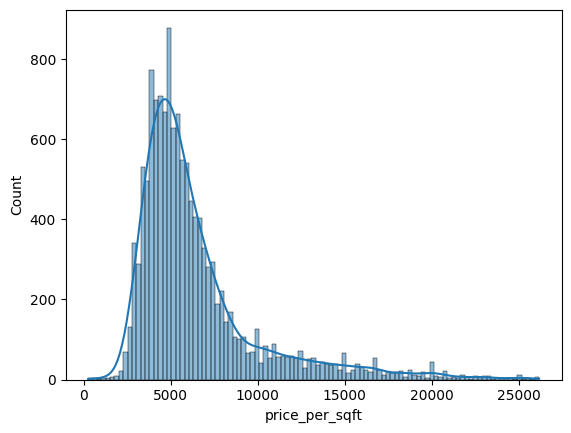

In [18]:
sns.histplot(df3['price_per_sqft'], kde=True)

In [19]:
min_per,max_per=df3.price_per_sqft.quantile([.001,.999])
min_per,max_per


(1364.68, 25000.0)

In [20]:
df4=df3[(df3['price_per_sqft']>min_per) & (df3['price_per_sqft']<max_per)]
df4.sample()

,location,size,total_sqft,bath,price,bhk,price_per_sqft,z_score
6520,Electronic City,2 BHK,1140.0,2.0,70.93,2,6221,-0.101033


In [21]:
df3.price_per_sqft.describe()

count    13106.000000
mean      6506.176331
std       3645.887753
min        267.000000
25%       4259.000000
50%       5416.000000
75%       7250.000000
max      26153.000000
Name: price_per_sqft, dtype: float64

<Axes: xlabel='price_per_sqft', ylabel='Count'>

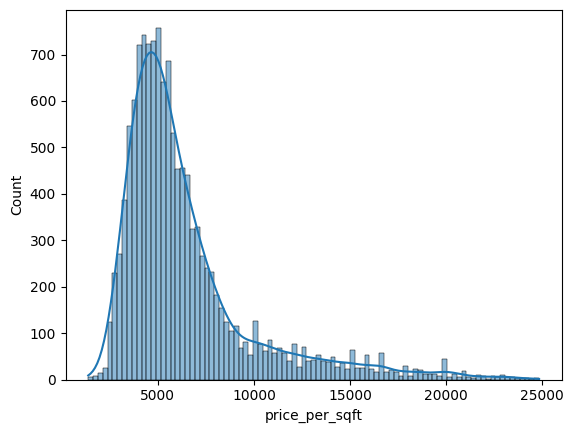

In [22]:
sns.histplot(df4['price_per_sqft'], kde=True)

In [23]:
df3.isnull().sum()

location          0
size              0
total_sqft        0
bath              0
price             0
bhk               0
price_per_sqft    0
z_score           0
dtype: int64

<Axes: ylabel='Frequency'>

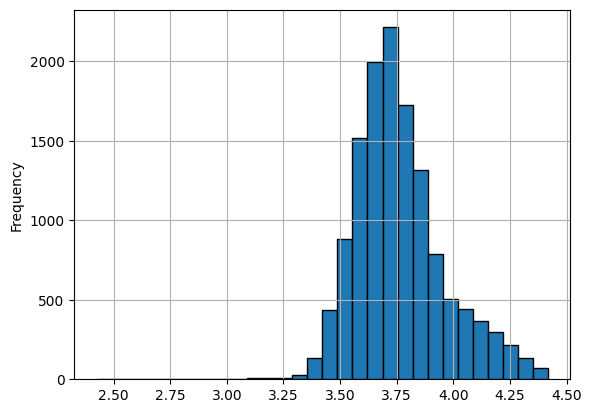

In [39]:
np.log10(df3.price_per_sqft).plot.hist(bins=30,edgecolor='black',grid=True)

<Axes: xlabel='price_per_sqft', ylabel='Count'>

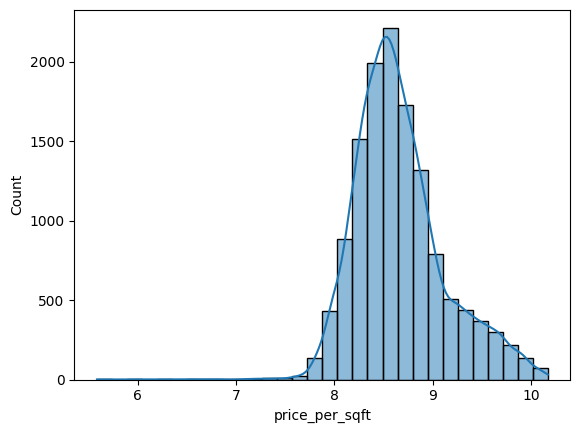

In [43]:
sns.histplot(np.log(df3.price_per_sqft), bins=30, kde=True)